In [10]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 812742
DATA_PATH = "/content/ETHUSD_1m_Binance.csv"

In [11]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
display(df.head())

(4278673, 12)


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,301.13,301.13,301.13,301.13,0.42643,2017-08-17 04:00:59.999,128.410866,2.0,0.42643,128.410866,0.0
1,2017-08-17 04:01:00,301.13,301.13,301.13,301.13,2.75787,2017-08-17 04:01:59.999,830.477393,4.0,2.75787,830.477393,0.0
2,2017-08-17 04:02:00,300.00,300.00,300.00,300.00,0.09930,2017-08-17 04:02:59.999,29.790000,2.0,0.09930,29.790000,0.0
3,2017-08-17 04:03:00,300.00,300.00,300.00,300.00,0.31389,2017-08-17 04:03:59.999,94.167000,3.0,0.00000,0.000000,0.0
4,2017-08-17 04:04:00,301.13,301.13,301.13,301.13,0.23202,2017-08-17 04:04:59.999,69.868183,1.0,0.23202,69.868183,0.0


In [12]:
CP1_MAX_ROWS = 100_000

df["Open time"] = pd.to_datetime(df["Open time"])
df = df.sort_values("Open time").reset_index(drop=True)

if len(df) > CP1_MAX_ROWS:
    df = df.iloc[-CP1_MAX_ROWS:].copy().reset_index(drop=True)

print("CP1 dataset shape:", df.shape)
print("Time range:", df["Open time"].min(), "->", df["Open time"].max())

drop_cols = ["Close time", "Ignore"]
existing_drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=existing_drop_cols)

numeric_cols = [c for c in df.columns if c != "Open time"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates()
df = df.dropna().reset_index(drop=True)

print(df.shape)

CP1 dataset shape: (100000, 12)
Time range: 2025-08-03 00:25:00 -> 2025-10-11 11:04:00
(100000, 10)


In [13]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()

    # basic candle features
    df["high_low_spread"] = df["High"] - df["Low"]
    df["close_open_diff"] = df["Close"] - df["Open"]

    # ratios
    eps = 1e-9
    df["taker_buy_ratio_base"] = df["Taker buy base asset volume"] / (df["Volume"] + eps)
    df["taker_buy_ratio_quote"] = df["Taker buy quote asset volume"] / (df["Quote asset volume"] + eps)

    # lag features
    for lag in [1, 5, 15]:
        df[f"close_lag_{lag}"] = df["Close"].shift(lag)
        df[f"volume_lag_{lag}"] = df["Volume"].shift(lag)
        df[f"trades_lag_{lag}"] = df["Number of trades"].shift(lag)

    # returns
    df["return_1"] = df["Close"].pct_change(1)
    df["return_5"] = df["Close"].pct_change(5)
    df["return_15"] = df["Close"].pct_change(15)

    # rolling stats
    for window in [5, 15, 60]:
        df[f"close_roll_mean_{window}"] = df["Close"].rolling(window).mean()
        df[f"close_roll_std_{window}"] = df["Close"].rolling(window).std()
        df[f"volume_roll_mean_{window}"] = df["Volume"].rolling(window).mean()
        df[f"volume_roll_std_{window}"] = df["Volume"].rolling(window).std()

    # target: next minute close
    df["target"] = df["Close"].shift(-1)

    return df

df_feat = add_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

print(df_feat.shape)
display(df_feat.head())

(99940, 39)


,Open time,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,volume_roll_std_5,close_roll_mean_15,close_roll_std_15,volume_roll_mean_15,volume_roll_std_15,close_roll_mean_60,close_roll_std_60,volume_roll_mean_60,volume_roll_std_60,target
0,2025-08-03 01:24:00,3414.84,3415.72,3412.90,3412.94,187.6645,6.408675e+05,2333.0,97.1397,331715.860463,...,41.064940,3411.747333,3.307225,164.802300,65.800515,3398.406667,15.577971,468.968200,547.987781,3417.73
1,2025-08-03 01:25:00,3412.93,3417.73,3412.50,3417.73,201.1745,6.871973e+05,2562.0,182.3107,622768.315593,...,33.057900,3411.977333,3.602704,167.424967,66.454529,3398.989000,15.637245,460.730555,548.240659,3421.78
2,2025-08-03 01:26:00,3417.73,3421.79,3416.49,3421.78,324.9755,1.111001e+06,4525.0,276.8872,946638.423095,...,63.042409,3412.387333,4.325518,170.502173,72.751397,3399.782167,15.564832,462.190057,547.752402,3419.08
3,2025-08-03 01:27:00,3421.78,3422.00,3417.45,3419.08,414.8413,1.418932e+06,4061.0,241.5524,826213.239233,...,95.141739,3412.573333,4.559006,178.728973,91.869215,3400.532500,15.387961,456.409235,546.366506,3419.26
4,2025-08-03 01:28:00,3419.03,3421.00,3418.72,3419.26,115.2178,3.939914e+05,2190.0,86.6470,296279.850437,...,119.605977,3412.861333,4.846573,180.919420,89.775223,3401.234500,15.262957,450.017632,548.103601,3421.10


In [14]:
feature_cols = [c for c in df_feat.columns if c not in ["Open time", "target"]]

n = len(df_feat)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_feat.iloc[:train_end].copy()
val_df = df_feat.iloc[train_end:val_end].copy()
test_df = df_feat.iloc[val_end:].copy()

X_train, y_train = train_df[feature_cols], train_df["target"]
X_val, y_val = val_df[feature_cols], val_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

print(X_train.shape, X_val.shape, X_test.shape)

(69958, 37) (14991, 37) (14991, 37)


In [15]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }

In [17]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=30,
        max_depth=8,
        random_state=SEED,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=SEED
    ),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_metrics = regression_metrics(y_val, val_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    results.append({
        "model": name,
        "val_MAE": val_metrics["MAE"],
        "val_RMSE": val_metrics["RMSE"],
        "val_R2": val_metrics["R2"],
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"],
    })

results_df = pd.DataFrame(results).sort_values("val_MAE")
display(results_df)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.00749e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


,model,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
1,Ridge,1.904513,3.019552,0.999643,2.459058,4.735167,0.999428
0,LinearRegression,1.905002,3.020269,0.999642,2.458439,4.731370,0.999428
2,RandomForest,3.090171,5.002293,0.999019,2.779208,5.198225,0.999310
3,HistGradientBoosting,7.311951,11.693367,0.994641,3.354233,7.042511,0.998734


In [18]:
# Наивный прогноз: следующая цена Close равна текущей Close
naive_pred = test_df["Close"].values
naive_metrics = regression_metrics(y_test.values, naive_pred)

print("Naive baseline:")
print(naive_metrics)

Naive baseline:
{'MAE': 2.447978120205452, 'RMSE': np.float64(4.660953095335843), 'R2': 0.9994453747259331}


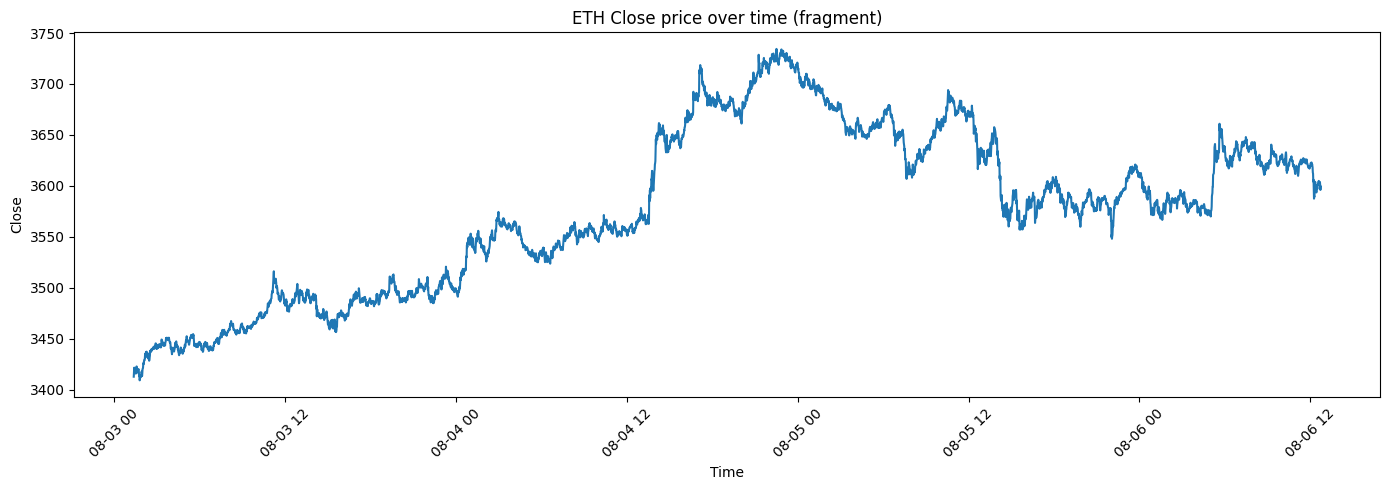

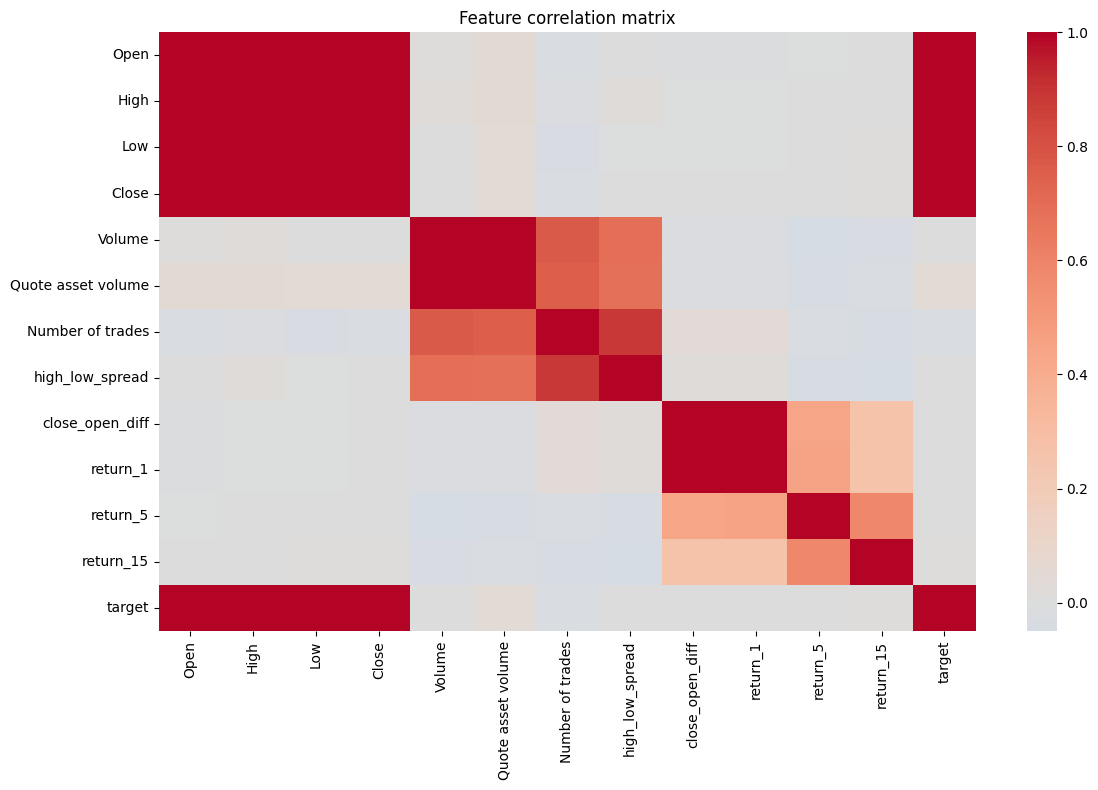

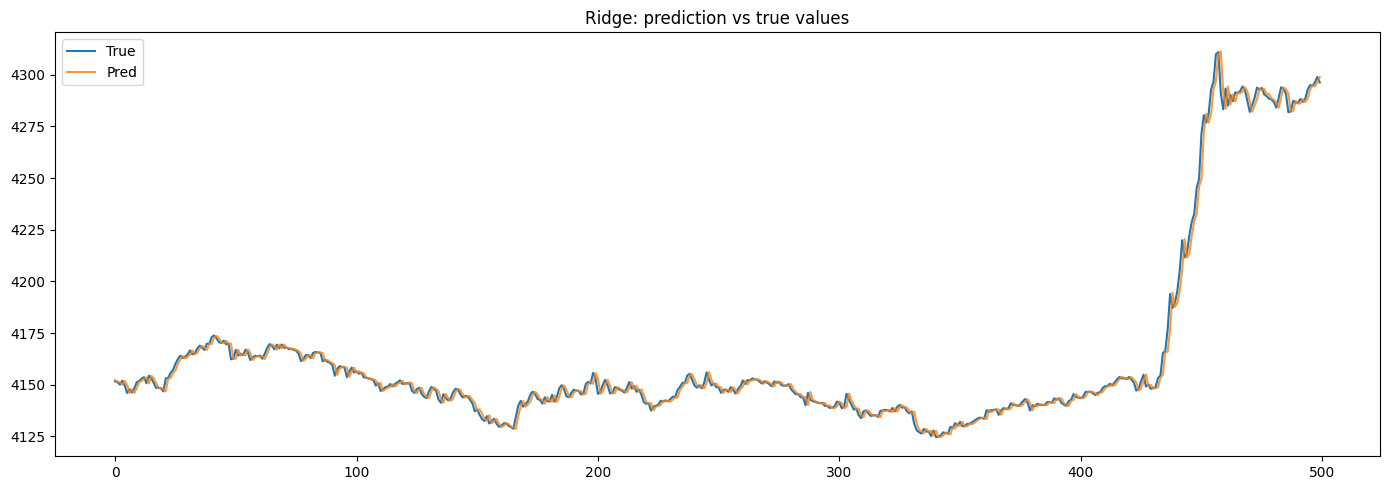

In [19]:
import matplotlib.pyplot as plt

# Close over time
plt.figure(figsize=(14, 5))
plt.plot(df_feat["Open time"].iloc[:5000], df_feat["Close"].iloc[:5000])
plt.title("ETH Close price over time (fragment)")
plt.xlabel("Time")
plt.ylabel("Close")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap (без seaborn можно обойтись, но seaborn в Colab тоже ок)
import seaborn as sns

corr_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "Quote asset volume", "Number of trades",
    "high_low_spread", "close_open_diff",
    "return_1", "return_5", "return_15", "target"
]
plt.figure(figsize=(12, 8))
sns.heatmap(df_feat[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Prediction vs target
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
pred = best_model.predict(X_test)

plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:500], label="True")
plt.plot(pred[:500], label="Pred", alpha=0.8)
plt.title(f"{best_model_name}: prediction vs true values")
plt.legend()
plt.tight_layout()
plt.show()